# 🎵 Chinook Music Store - Data Analysis & Visualizations

## Step 1: Database Connection

In [19]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=JAFFERMIYA;'
    'DATABASE=Chinook;'
    'Trusted_Connection=yes;'
)

print("Connected Successfully!")


Connected Successfully!


## Step 2: Load Tables

In [20]:
# Load main tables
df_album = pd.read_sql("SELECT * FROM Album", conn)
df_artist = pd.read_sql("SELECT * FROM Artist", conn)
df_customer = pd.read_sql("SELECT * FROM Customer", conn)
df_employee = pd.read_sql("SELECT * FROM Employee", conn)
df_genre = pd.read_sql("SELECT * FROM Genre", conn)
df_invoice = pd.read_sql("SELECT * FROM Invoice", conn)
df_invoiceline = pd.read_sql("SELECT * FROM InvoiceLine", conn)
df_mediatype = pd.read_sql("SELECT * FROM MediaType", conn)
df_playlist = pd.read_sql("SELECT * FROM Playlist", conn)
df_playlisttrack = pd.read_sql("SELECT * FROM PlaylistTrack", conn)
df_track = pd.read_sql("SELECT * FROM Track", conn)

print("All 11 tables loaded successfully!")

C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1052864061.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_album = pd.read_sql("SELECT * FROM Album", conn)
C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1052864061.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_artist = pd.read_sql("SELECT * FROM Artist", conn)
C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1052864061.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("SELECT * FROM Customer", conn)
C:\Users\jaffe\AppData\Loc

All 11 tables loaded successfully!


---
## Chart 1: Top 10 Selling Artists
**Business Question:** Which artists generate the highest sales revenue?

C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1407264072.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales, y=artists, palette='rocket')


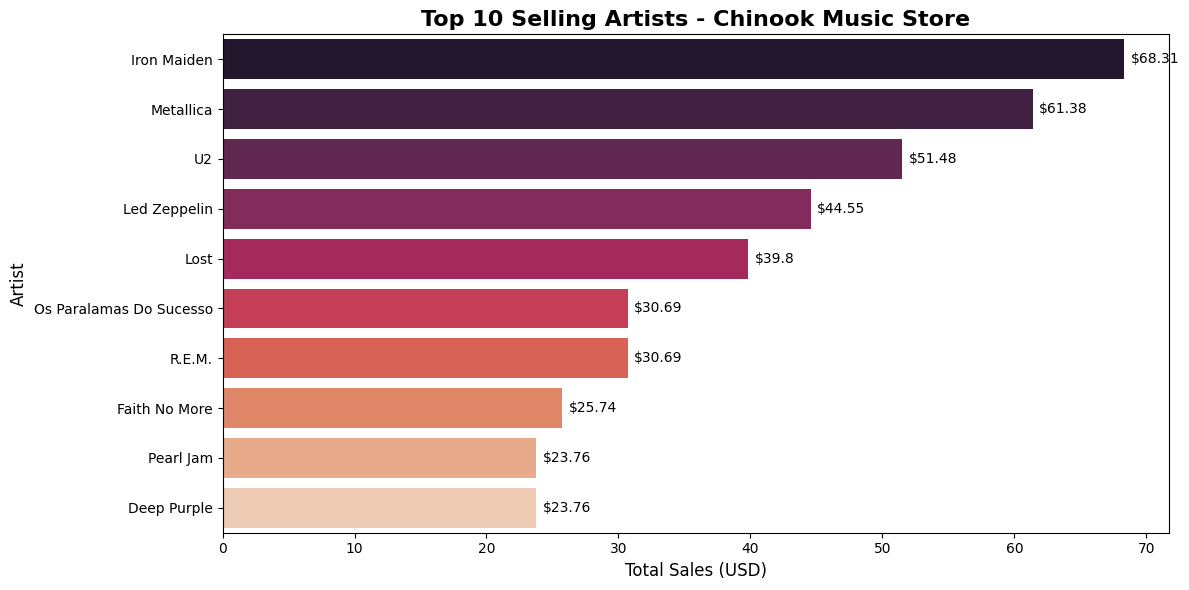

Chart saved!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from your SQL query
artists = ['Iron Maiden', 'Metallica', 'U2', 'Led Zeppelin', 'Lost', 
           'Os Paralamas Do Sucesso', 'R.E.M.', 'Faith No More', 'Pearl Jam', 'Deep Purple']

sales = [68.31, 61.38, 51.48, 44.55, 39.80, 30.69, 30.69, 25.74, 23.76, 23.76]

# Create figure
plt.figure(figsize=(12, 6))
sns.barplot(x=sales, y=artists, palette='rocket')

# Labels
plt.title('Top 10 Selling Artists - Chinook Music Store', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales (USD)', fontsize=12)
plt.ylabel('Artist', fontsize=12)

# Add value labels on bars
for i, v in enumerate(sales):
    plt.text(v + 0.5, i, f'${v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_artists.png', dpi=150)
plt.show()

print("Chart saved!")

In [5]:
# Pull directly from DB
df_artists = pd.read_sql("""
    SELECT TOP 10 ar.Name AS Artist,
           SUM(il.UnitPrice * il.Quantity) AS TotalSales
    FROM InvoiceLine il
    JOIN Track t ON il.TrackId = t.TrackId
    JOIN Album al ON t.AlbumId = al.AlbumId
    JOIN Artist ar ON al.ArtistId = ar.ArtistId
    GROUP BY ar.ArtistId, ar.Name
    ORDER BY TotalSales DESC
""", conn)

print(df_artists)

                    Artist  TotalSales
0              Iron Maiden       68.31
1                Metallica       61.38
2                       U2       51.48
3             Led Zeppelin       44.55
4                     Lost       39.80
5  Os Paralamas Do Sucesso       30.69
6                   R.E.M.       30.69
7            Faith No More       25.74
8                Pearl Jam       23.76
9              Deep Purple       23.76


C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\998310521.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_artists = pd.read_sql("""


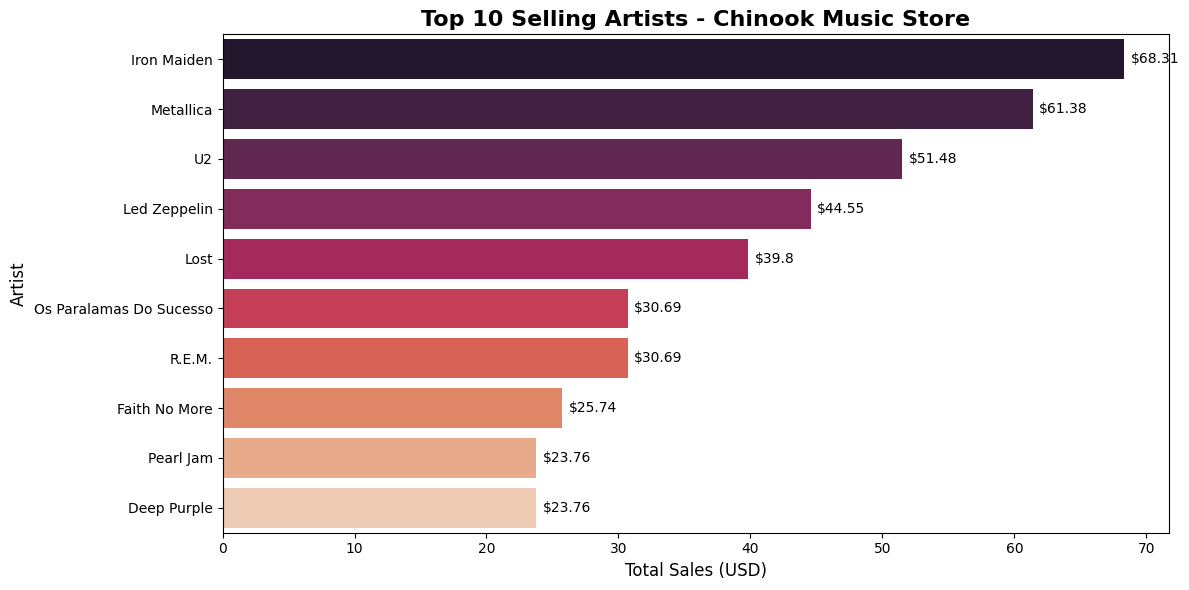

Chart 1 Done!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='TotalSales', y='Artist', data=df_artists, hue='Artist', palette='rocket', legend=False)
# Title and labels
plt.title('Top 10 Selling Artists - Chinook Music Store', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales (USD)', fontsize=12)
plt.ylabel('Artist', fontsize=12)

# Add value labels on bars
for i, v in enumerate(df_artists['TotalSales']):
    plt.text(v + 0.5, i, f'${v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_artists.png', dpi=150)
plt.show()

print("Chart 1 Done!")

### 💡 Insight:
Iron Maiden leads all artists with 68.31 USD in total sales, 
followed by Metallica at 61.38 USD.

---

## Chart 2: Most Popular Music Genres
**Business Question:** Which music genres are purchased the most?

In [8]:
df_genre = pd.read_sql("""
     SELECT TOP 5 
       g.GenreId,
       g.Name AS Genre,
       SUM(il.Quantity) AS TracksSold
FROM Genre g
JOIN Track t
     ON g.GenreId = t.GenreId
JOIN InvoiceLine il
     ON t.TrackId = il.TrackId
GROUP BY g.GenreId, g.Name
ORDER BY TracksSold DESC
""", conn)

print(df_genre)

   GenreId               Genre  TracksSold
0        1                Rock         487
1        7               Latin         207
2        4  Alternative & Punk         158
3        3               Metal         146
4        2                Jazz          44


C:\Users\jaffe\AppData\Local\Temp\ipykernel_9380\945495360.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_genre = pd.read_sql("""


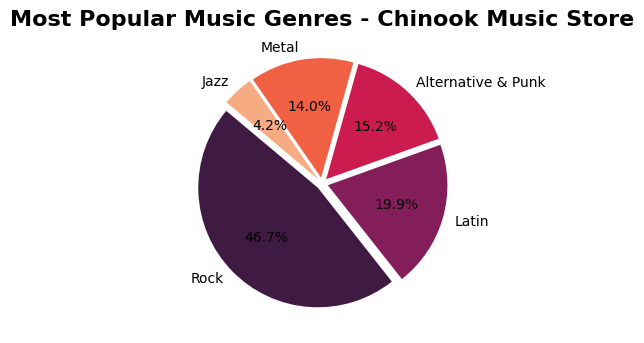

Chart 2 Done! ✅


In [11]:
plt.figure(figsize=(4, 4))
plt.pie(df_genre['TracksSold'], 
        labels=df_genre['Genre'],
        autopct='%1.1f%%',
        colors=sns.color_palette('rocket', len(df_genre)),
        startangle=140,
        explode=[0.05, 0.05, 0.05, 0.05, 0.05])

plt.title('Most Popular Music Genres - Chinook Music Store', 
          fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_genre_popularity.png', dpi=150)
plt.show()

print("Chart 2 Done! ✅")

### 💡 Insight:
Rock dominates genre popularity with 47.1% of total tracks sold,
nearly double Latin which comes second at 20%.

---

## 📊 Chart 3: Top Revenue Generating Genres

**Business Question:** Which music genres generate the highest total revenue?

In [4]:
df_genre_revenue = pd.read_sql("""
    select top 5 g.genreid,g.Name,
 sum(il.Unitprice*il.quantity) as Total_revenue
 from genre g
join Track t
on g.genreid=t.genreid
join InvoiceLine il
on t.TrackId=il.trackid
 group by g.genreid,g.Name
order by Total_revenue desc
""", conn)

print(df_genre_revenue)

C:\Users\jaffe\AppData\Local\Temp\ipykernel_40984\3770602649.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_genre_revenue = pd.read_sql("""


   genreid                Name  Total_revenue
0        1                Rock         482.13
1        7               Latin         204.93
2        4  Alternative & Punk         156.42
3        3               Metal         144.54
4        2                Jazz          43.56


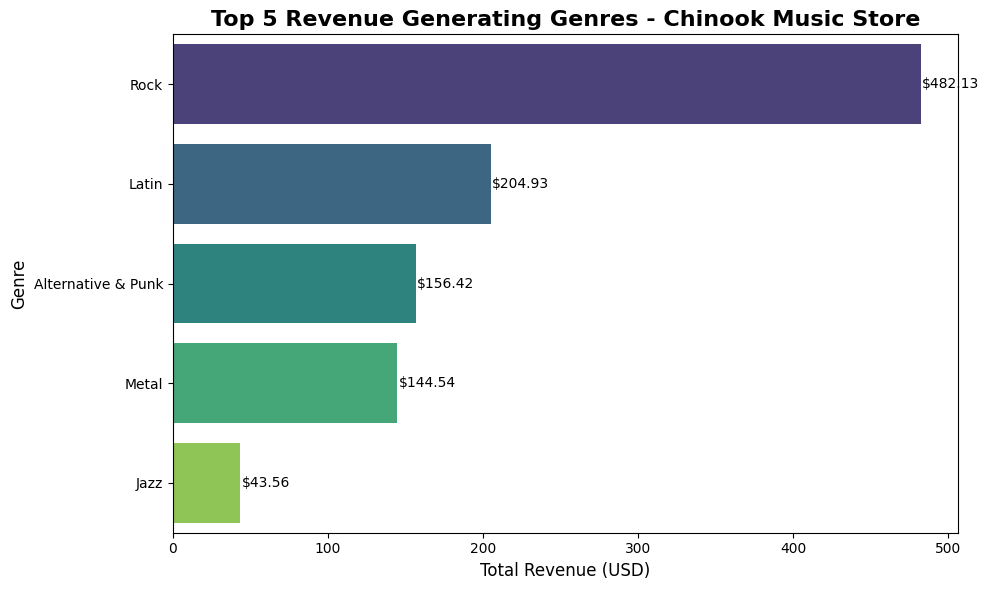

Chart 3 Done! ✅


In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_revenue', y='Name', data=df_genre_revenue,
            hue='Name', palette='viridis', legend=False)

plt.title('Top 5 Revenue Generating Genres - Chinook Music Store', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Genre', fontsize=12)

for i, v in enumerate(df_genre_revenue['Total_revenue']):
    plt.text(v + 1, i, f'${v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart3_genre_revenue.png', dpi=150)
plt.show()

print("Chart 3 Done! ✅")

### 💡 Insight:
Rock dominates genre revenue with USD 482.13, nearly double Latin which comes second at USD 204.93. Jazz contributes the least at USD 43.56 indicating niche audience preference.

---
## Chart 4: Revenue by Country
**Business Question:** Which countries generate the highest revenue?

In [12]:
df_country_revenue = pd.read_sql(""" select top 10 BillingCountry,
   sum(total) as total_revenue_by_country
   from Invoice
   group by BillingCountry
   order by total_revenue_by_country desc """, conn) 

print(df_country_revenue)

C:\Users\jaffe\AppData\Local\Temp\ipykernel_40984\1953554581.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_country_revenue = pd.read_sql(""" select top 10 BillingCountry,


   BillingCountry  total_revenue_by_country
0             USA                    523.06
1          Canada                    303.96
2          France                    195.10
3          Brazil                    190.10
4         Germany                    156.48
5  United Kingdom                    112.86
6  Czech Republic                     90.24
7        Portugal                     77.24
8           India                     75.26
9           Chile                     46.62


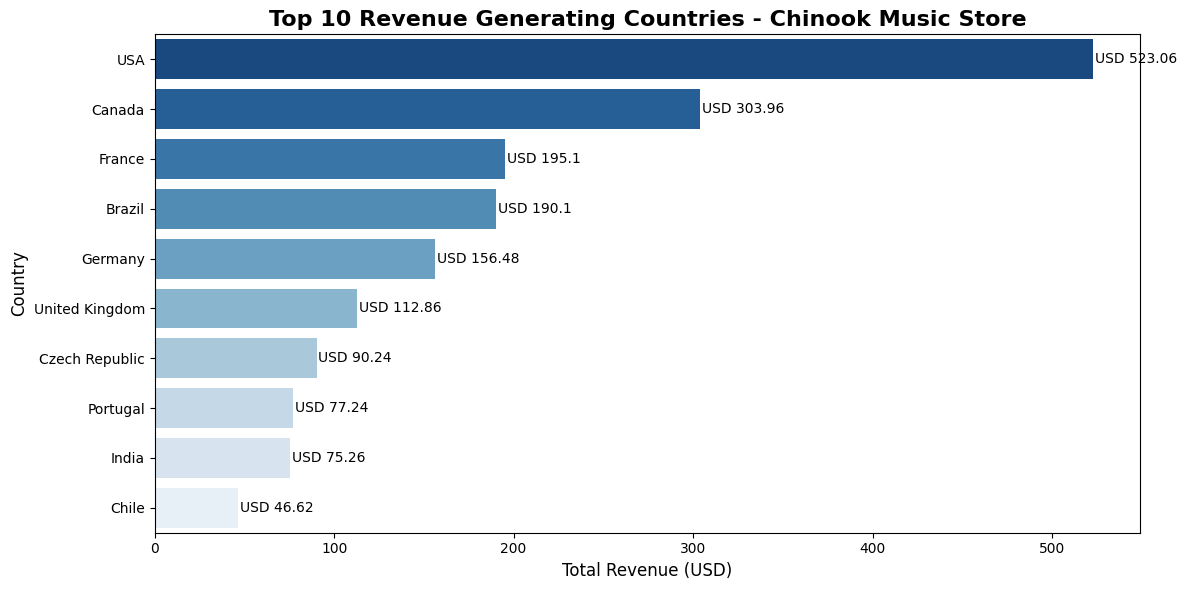

Chart 4 Done! ✅


In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x='total_revenue_by_country', y='BillingCountry', 
            data=df_country_revenue,
            hue='BillingCountry', palette='Blues_r', legend=False)

plt.title('Top 10 Revenue Generating Countries - Chinook Music Store', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)

for i, v in enumerate(df_country_revenue['total_revenue_by_country']):
    plt.text(v + 1, i, f'USD {v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart4_revenue_by_country.png', dpi=150)
plt.show()

print("Chart 4 Done! ✅")

### 💡 Insight:
USA leads all countries with USD 523.06 in total revenue, making it the largest market for Chinook Music Store. 
Canada and France follow as second and third strongest markets. 
India appears in top 10 at USD 75.26 showing emerging market potential.

In [4]:
print(conn)

In [7]:
df_top_customers = pd.read_sql("""
    SELECT TOP 10 c.CustomerId,
       c.FirstName+' '+c.LastName as Name,
       SUM(i.Total) AS TotalSpent
FROM Customer c
JOIN Invoice i
ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId, c.FirstName, c.LastName
ORDER BY TotalSpent DESC
""", conn)

print(df_top_customers)

   CustomerId                Name  TotalSpent
0           6         Helena Holý       49.62
1          26  Richard Cunningham       47.62
2          57          Luis Rojas       46.62
3          45     Ladislav Kovács       45.62
4          46       Hugh O'Reilly       45.62
5          37     Fynn Zimmermann       43.62
6          28       Julia Barnett       43.62
7          24       Frank Ralston       43.62
8          25      Victor Stevens       42.62
9           7       Astrid Gruber       42.62


C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1492732488.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_customers = pd.read_sql("""


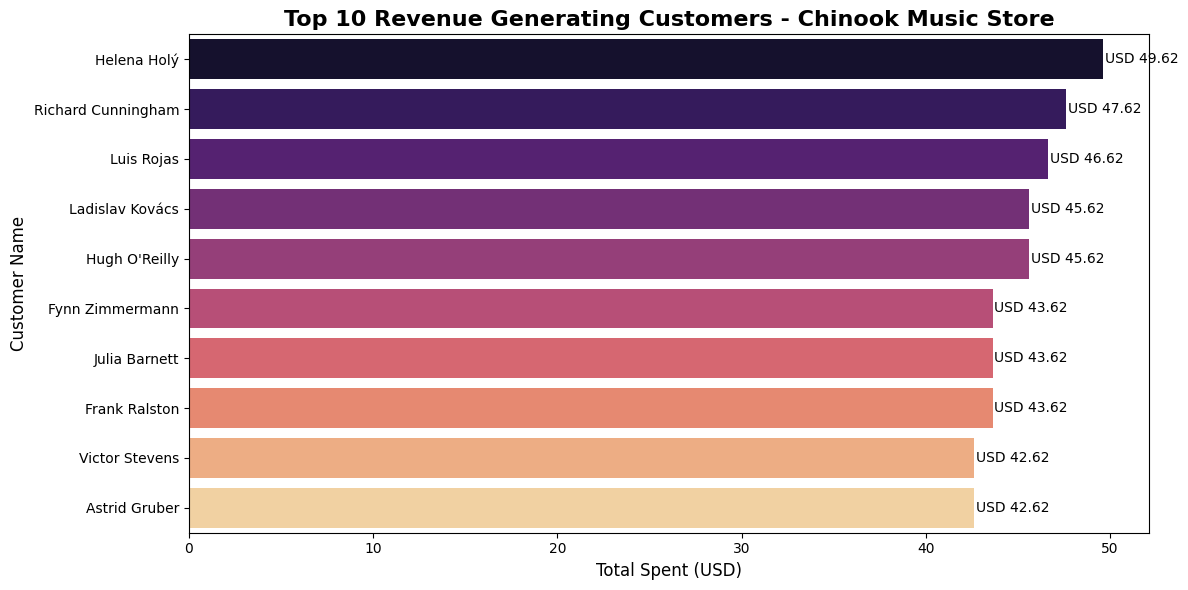

Chart 5 Done! ✅


In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(x='TotalSpent', y='Name', 
            data=df_top_customers,
            hue='Name', palette='magma', legend=False)

plt.title('Top 10 Revenue Generating Customers - Chinook Music Store', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Spent (USD)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)

for i, v in enumerate(df_top_customers['TotalSpent']):
    plt.text(v + 0.1, i, f'USD {v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart5_top_customers.png', dpi=150)
plt.show()

print("Chart 5 Done! ✅")

### Insight:
Helena Holý leads all customers with USD 49.62 in total spending, followed by Richard Cunningham at USD 47.62.
Top 10 customers show similar spending patterns ranging between USD 42 to 50, indicating balanced revenue contribution.

---

## 📊 Chart 5: Top Revenue Generating Customers
**Business Question:** Which customers generate the highest revenue in Chinook Music Store?

In [13]:
df_top_customer_country = pd.read_sql("""
    select * 
 from
 (
 select c.customerid,c.FirstName +' '+c.LastName as Name,
 i.Billingcountry,
 sum(i.total) as Total_revenue_country,
 row_number() over(partition by Billingcountry order by sum(i.total) desc )as rn
 from Customer c
 join invoice i
 on c.CustomerId=i.CustomerID
 group by c.customerid,c.FirstName,c.LastName,i.Billingcountry
 ) t
 where rn=1
 order by Total_revenue_country DESC
""", conn)

print(df_top_customer_country)

C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1364501741.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_customer_country = pd.read_sql("""


    customerid                   Name  Billingcountry  Total_revenue_country  \
0            6            Helena Holý  Czech Republic                  49.62   
1           26     Richard Cunningham             USA                  47.62   
2           57             Luis Rojas           Chile                  46.62   
3           45        Ladislav Kovács         Hungary                  45.62   
4           46          Hugh O'Reilly         Ireland                  45.62   
5           37        Fynn Zimmermann         Germany                  43.62   
6            7          Astrid Gruber         Austria                  42.62   
7           44       Terhi Hämäläinen         Finland                  41.62   
8           43       Isabelle Mercier          France                  40.62   
9           48  Johannes Van der Berg     Netherlands                  40.62   
10           4           Bjørn Hansen          Norway                  39.62   
11          34         João Fernandes   

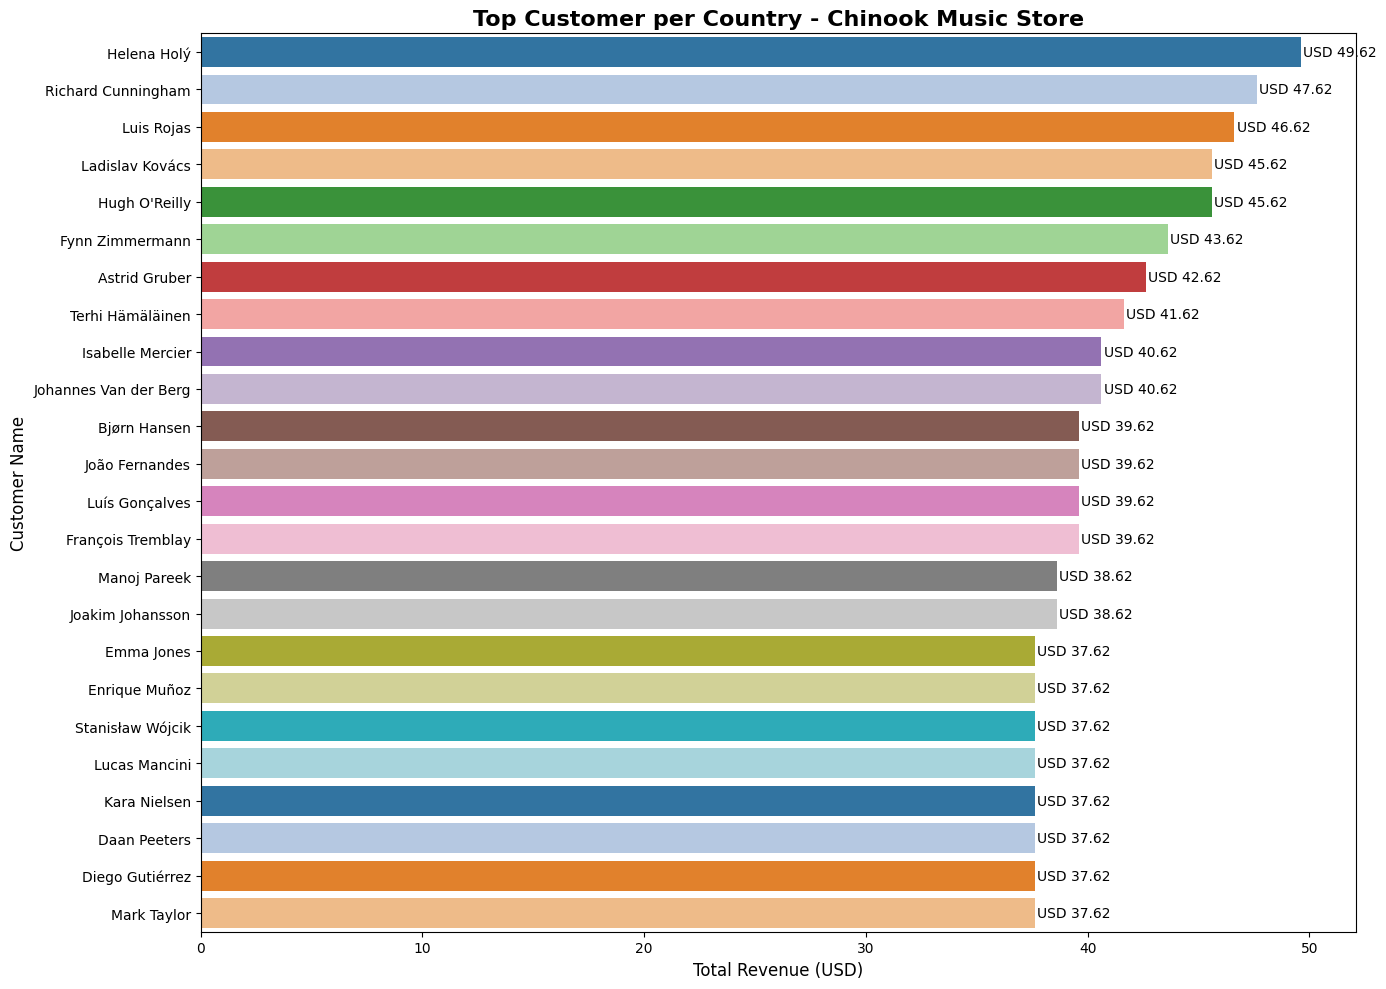

Chart 6 Done! ✅


In [14]:
plt.figure(figsize=(14, 10))
sns.barplot(x='Total_revenue_country', y='Name', 
            data=df_top_customer_country,
            hue='Billingcountry', palette='tab20', legend=False)

plt.title('Top Customer per Country - Chinook Music Store', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)

for i, v in enumerate(df_top_customer_country['Total_revenue_country']):
    plt.text(v + 0.1, i, f'USD {v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart6_top_customer_country.png', dpi=150)
plt.show()

print("Chart 6 Done! ✅")


In [18]:
# Adding country name beside customer name for better chart readability
df_top_customer_country['Name'] = df_top_customer_country['Name'] + ' (' + df_top_customer_country['Billingcountry'] + ')'

print(df_top_customer_country)

    customerid                                               Name  \
0            6      Helena Holý (Czech Republic) (Czech Republic)   
1           26                     Richard Cunningham (USA) (USA)   
2           57                         Luis Rojas (Chile) (Chile)   
3           45                Ladislav Kovács (Hungary) (Hungary)   
4           46                  Hugh O'Reilly (Ireland) (Ireland)   
5           37                Fynn Zimmermann (Germany) (Germany)   
6            7                  Astrid Gruber (Austria) (Austria)   
7           44               Terhi Hämäläinen (Finland) (Finland)   
8           43                 Isabelle Mercier (France) (France)   
9           48  Johannes Van der Berg (Netherlands) (Netherlands)   
10           4                     Bjørn Hansen (Norway) (Norway)   
11          34               João Fernandes (Portugal) (Portugal)   
12           1                   Luís Gonçalves (Brazil) (Brazil)   
13           3                Fran

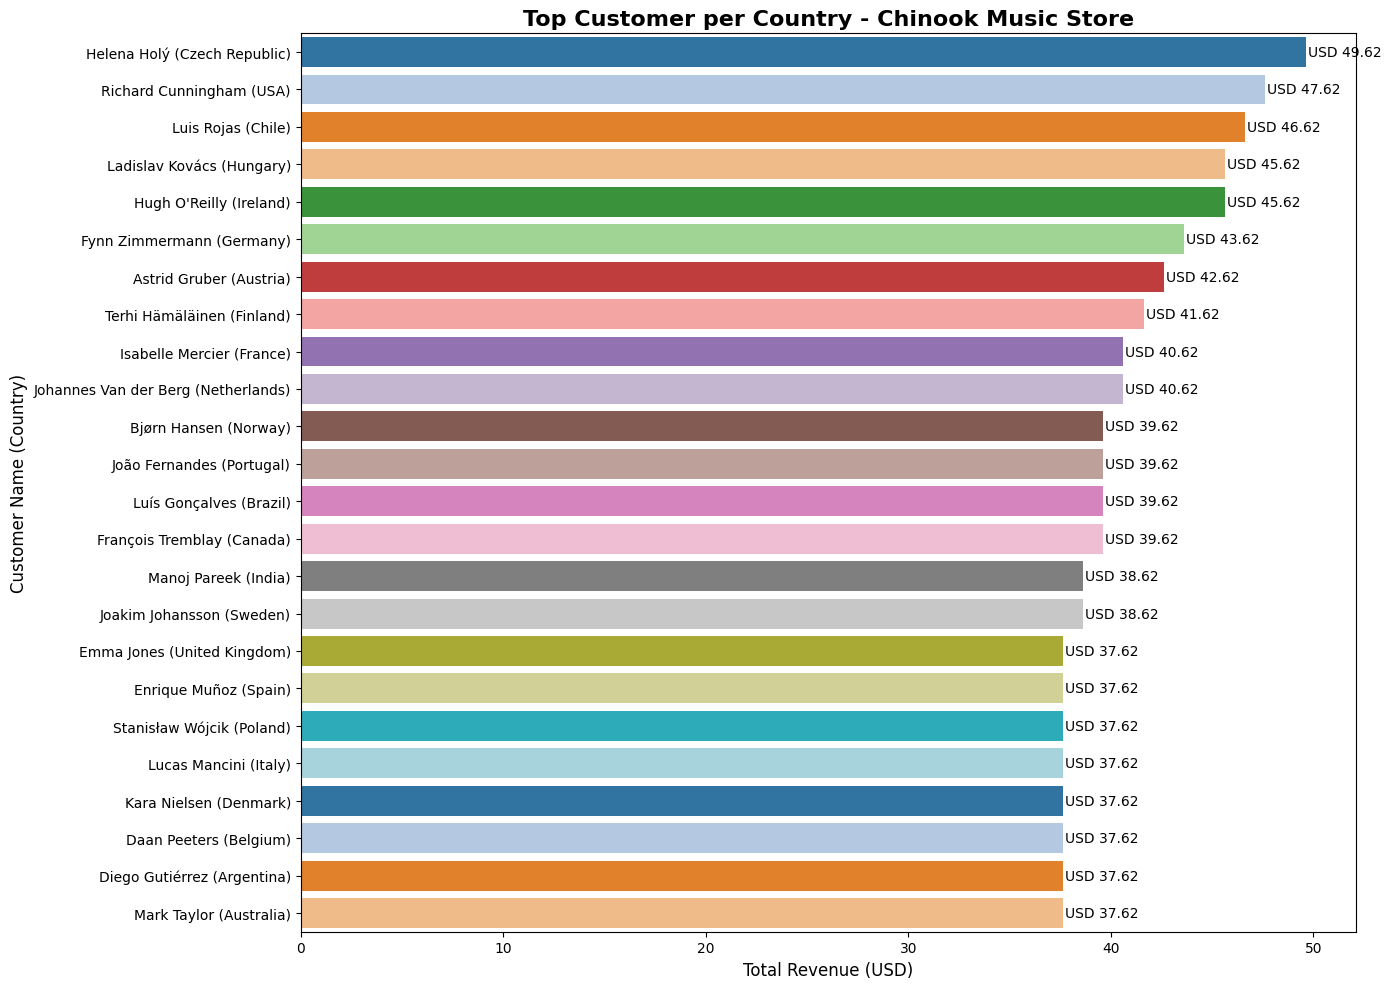

Chart 6 Done! ✅


In [16]:
plt.figure(figsize=(14, 10))
sns.barplot(x='Total_revenue_country', y='Name', 
            data=df_top_customer_country,
            hue='Name', palette='tab20', legend=False)

plt.title('Top Customer per Country - Chinook Music Store', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Customer Name (Country)', fontsize=12)

for i, v in enumerate(df_top_customer_country['Total_revenue_country']):
    plt.text(v + 0.1, i, f'USD {v}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart6_top_customer_country.png', dpi=150)
plt.show()

print("Chart 6 Done! ✅")

### Insight:
Helena Holý from Czech Republic leads all countries with USD 49.62 in total spending. Richard Cunningham represents 
USA at USD 47.62. Most top customers across countries spend between USD 37 to 50, showing consistent revenue distribution globally.

---

## Chart 7: Best Selling Track per Genre
**Business Question:** Which track is the most purchased within each genre in the Chinook Music Store?

In [21]:
df_best_track_genre = pd.read_sql("""
    SELECT GenreName, TrackName, TrackSold
    FROM (
        SELECT g.Name AS GenreName,
               t.Name AS TrackName,
               SUM(il.Quantity) AS TrackSold,
               ROW_NUMBER() OVER (PARTITION BY g.Name 
                                  ORDER BY SUM(il.Quantity) DESC) AS rn
        FROM Genre g
        JOIN Track t ON g.GenreId = t.GenreId
        JOIN InvoiceLine il ON t.TrackId = il.TrackId
        GROUP BY g.Name, t.Name
    ) t
    WHERE rn = 1
    ORDER BY TrackSold DESC
""", conn)

print(df_best_track_genre)

C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1719024006.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_best_track_genre = pd.read_sql("""


             GenreName                    TrackName  TrackSold
0                 Rock           Dazed and Confused          4
1   Alternative & Punk                     Untitled          2
2                Blues                  Travis Walk          2
3                Drama                      The Fix          2
4          Hip Hop/Rap          Nega Do Cabelo Duro          2
5                 Jazz           End Of Romanticism          2
6                Latin                    Meditação          2
7                Metal            Master Of Puppets          2
8                  Pop             Gimme Some Truth          2
9             R&B/Soul            Save The Children          2
10              Reggae                   Firmamento          2
11     Science Fiction               The Woman King          2
12          Soundtrack                     Plot 180          2
13            TV Shows                    Walkabout          2
14               World                       Já Foi    

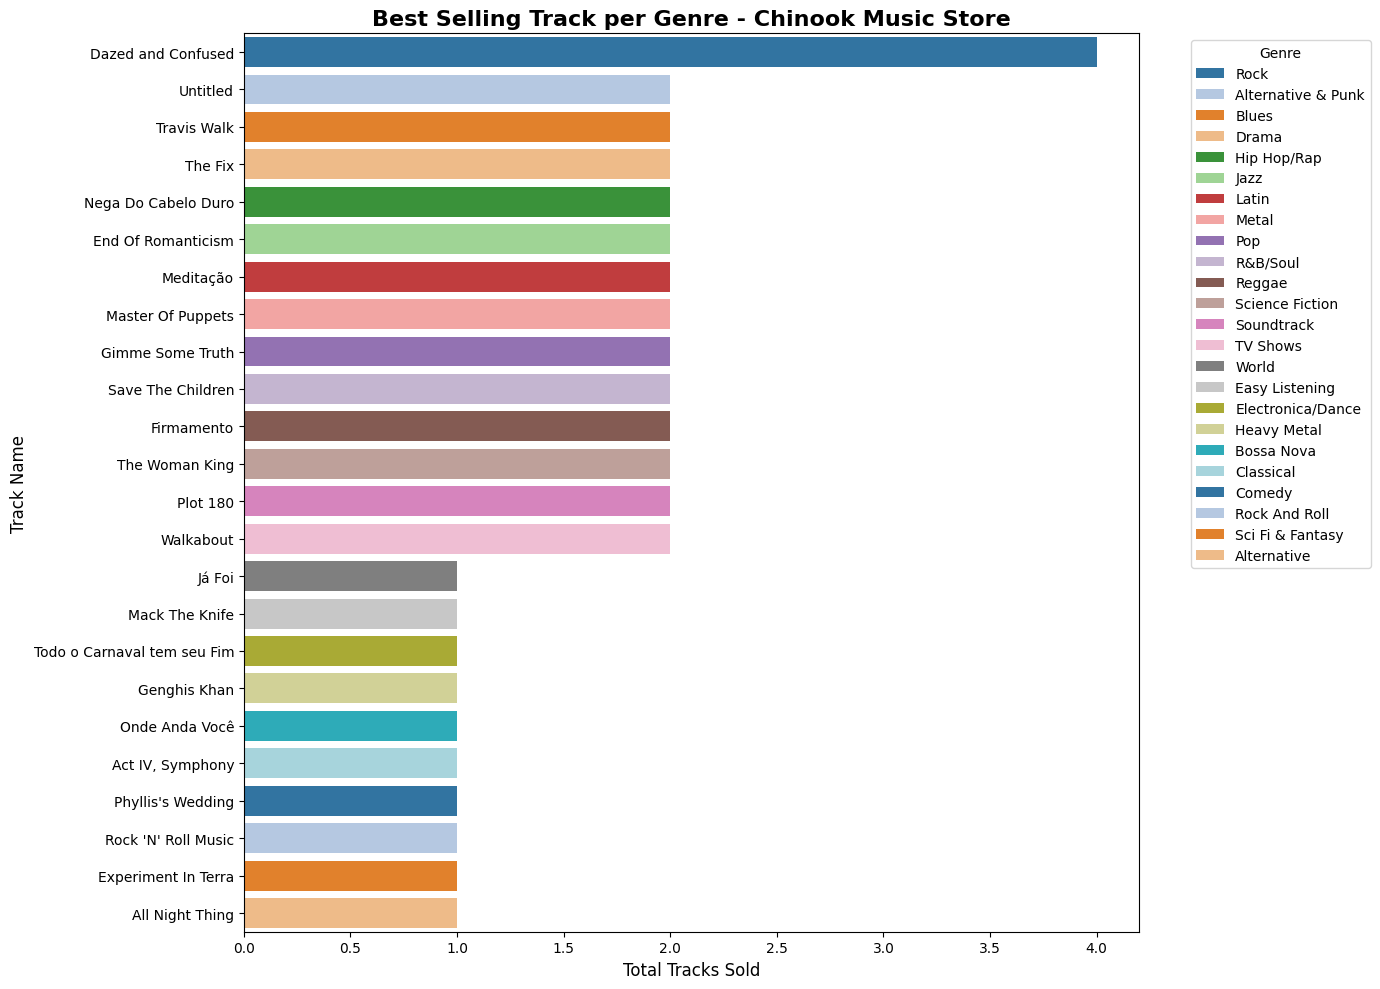

Chart 7 Done! ✅


In [22]:
plt.figure(figsize=(14, 10))
sns.barplot(x='TrackSold', y='TrackName', 
            data=df_best_track_genre,
            hue='GenreName', palette='tab20', legend=True)

plt.title('Best Selling Track per Genre - Chinook Music Store', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Tracks Sold', fontsize=12)
plt.ylabel('Track Name', fontsize=12)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('chart7_best_track_genre.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 7 Done! ✅")

### Insight:
Dazed and Confused from Rock genre leads all tracks with 4 total sales. Most genres show equal purchase counts of 1 to 2, indicating diverse customer preferences with no single dominant track across genres.

---

## Chart 8: Monthly Revenue Trend
**Business Question:** How does revenue change over time on a monthly basis in the Chinook Music Store?

In [24]:
df_monthly_revenue = pd.read_sql("""
       select year(invoicedate) as Year,
            month(invoicedate) as Month,
            sum(total) as Total
from INVOICE
group by Year(invoicedate),Month(invoicedate)
order by Year,Month
""", conn)

print(df_monthly_revenue)

    Year  Month  Total
0   2021      1  35.64
1   2021      2  37.62
2   2021      3  37.62
3   2021      4  37.62
4   2021      5  37.62
5   2021      6  37.62
6   2021      7  37.62
7   2021      8  37.62
8   2021      9  37.62
9   2021     10  37.62
10  2021     11  37.62
11  2021     12  37.62
12  2022      1  52.62
13  2022      2  46.62
14  2022      3  44.62
15  2022      4  37.62
16  2022      5  37.62
17  2022      6  37.62
18  2022      7  37.62
19  2022      8  37.62
20  2022      9  36.63
21  2022     10  37.62
22  2022     11  37.62
23  2022     12  37.62
24  2023      1  37.62
25  2023      2  37.62
26  2023      3  37.62
27  2023      4  51.62
28  2023      5  42.62
29  2023      6  50.62
30  2023      7  37.62
31  2023      8  37.62
32  2023      9  37.62
33  2023     10  37.62
34  2023     11  23.76
35  2023     12  37.62
36  2024      1  37.62
37  2024      2  37.62
38  2024      3  37.62
39  2024      4  37.62
40  2024      5  37.62
41  2024      6  37.62
42  2024   

C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\1290963968.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly_revenue = pd.read_sql("""


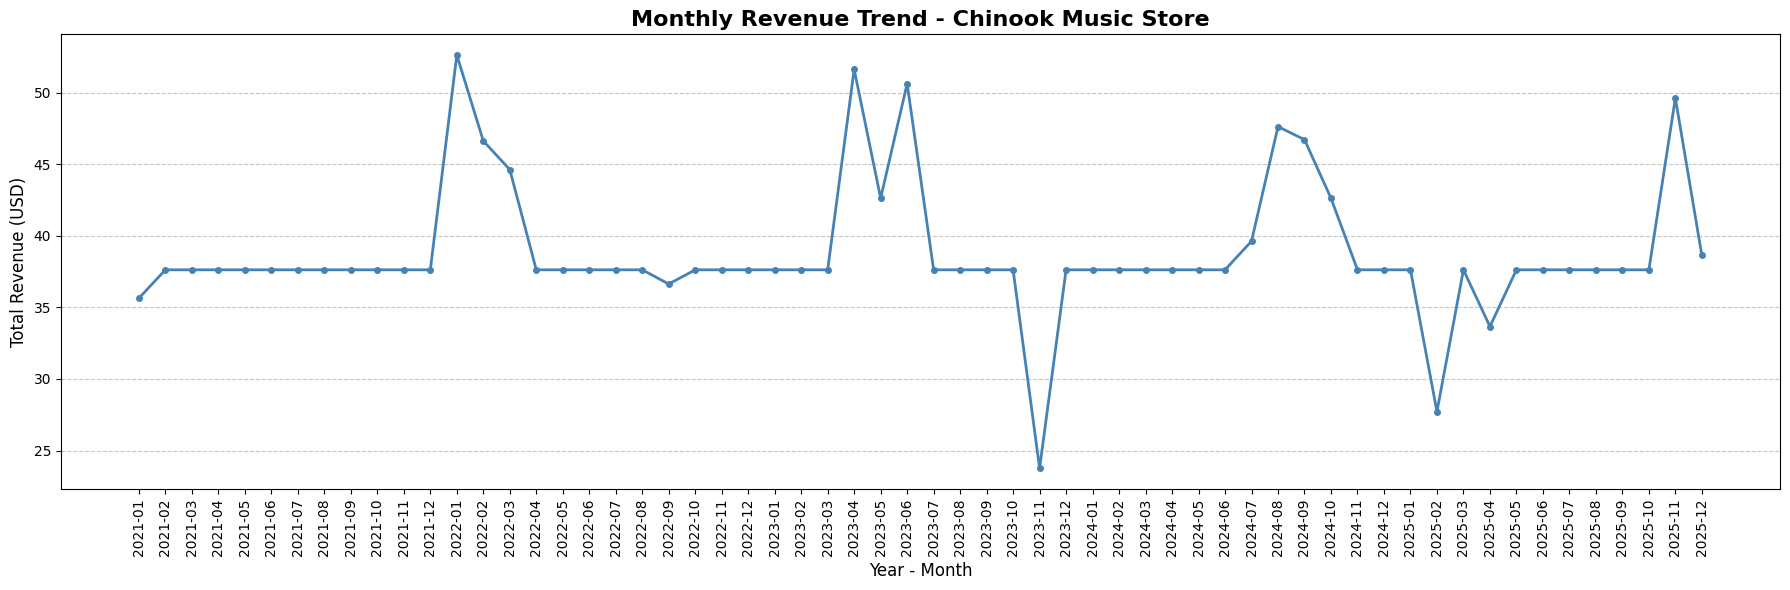

Chart 8 Done! ✅


In [25]:
# Create Year-Month column for better x axis display
df_monthly_revenue['Year_Month'] = df_monthly_revenue['Year'].astype(str) + '-' + df_monthly_revenue['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(18, 6))
plt.plot(df_monthly_revenue['Year_Month'], 
         df_monthly_revenue['Total'], 
         marker='o', color='steelblue', linewidth=2, markersize=4)

plt.title('Monthly Revenue Trend - Chinook Music Store', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year - Month', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('chart8_monthly_revenue_trend.png', dpi=150)
plt.show()

print("Chart 8 Done! ✅")

###  Insight:
Monthly revenue remains stagnant between USD 35 to 52 over 5 years (2021-2025), showing no significant growth trend.
Occasional spikes appear in certain months but revenue quickly returns to baseline of USD 37.62.
This indicates the business needs new customer acquisition strategies, marketing campaigns and product expansion to drive revenue growth.

---

## Chart 9: Sales Representative Performance
**Business Question:** Which sales representatives generate the highest revenue in Chinook Music Store?

In [26]:
df_sales_rep = pd.read_sql("""
    select e.employeeId, e.Firstname +' '+e.lastname as Sales_Rep_Name, 
    sum(i.total) as Total_Revenue
from Employee e
join Customer c
on e.EmployeeId=c.SupportRepId
join invoice i
on c.CustomerID=i.CustomerID
group by e.employeeId, e.Firstname,e.lastname
order by Total_Revenue desc
""", conn)

print(df_sales_rep)

   employeeId Sales_Rep_Name  Total_Revenue
0           3   Jane Peacock         833.04
1           4  Margaret Park         775.40
2           5  Steve Johnson         720.16


C:\Users\jaffe\AppData\Local\Temp\ipykernel_38880\3698513966.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales_rep = pd.read_sql("""
